
# Lab 8: Monte Carlo Markov Chain (MCMC)

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">



Nota: La mayor parte de códigos no los desarrolle en este curso, si no que son copy-paste de un proyecto pasado que hice para otro curso, dónde parti del modelo de ising y encontramos la temperatura critica a partir de métodos de machine learning con distintos enfoques, uno de ellos la clasificación de estado ferro y paramagnetico, y el modelo se empieza a equivocar al rededor de la temperatura critica. El otro enfoque fue imputar de manera aleatoria spines y pasar la red con "huecos" por una unet, a medida que la red se confunde más para predecir el spin faltante, la metrica de confusión empieza a ser más alta cerca de la temperatura critica. 

https://github.com/JD314/Ising_ML


1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona* un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema. 
            Si la energía disminuye se acepta la nueva configuración $x'$. 
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.



In [4]:
import numpy as np
from numba import njit

class Ising_2D:

    def __init__(self):
        self.T_c = 2 / np.log(1 + np.sqrt(2))
        pass

    # Condiciones de frontera periódicas
    def pbc(self, i):
        """Condiciones de frontera periódicas."""
        if i + 1 > self.L - 1:
            return 0
        elif i - 1 < 0:
            return self.L - 1
        else:
            return i

    # Cálculo de la energía local, interacción de primeros vecinos
    def energy(self, spin, i, j):
        """Calcula la energía local de un espín en la red."""
        return -self.J * spin[i, j] * (
            spin[self.pbc(i - 1), j] +
            spin[self.pbc(i + 1), j] +
            spin[i, self.pbc(j - 1)] +
            spin[i, self.pbc(j + 1)]
        ) + spin[i, j] * self.H

    # Microestado inicial aleatorio (T = ∞, H = 0)
    def build_system(self):
        """Construye una red inicial de espines aleatorios ±1."""
        # spin = np.random.randint(0, 2, (self.L, self.L))
        spin = np.ones((self.L, self.L))
        spin[spin == 0] = -1
        self.spin = spin
    
    def total_energy(self):
        """Calcula la energía total del sistema."""
        energy = 0.0
        # Interacciones horizontales
        energy -= self.J * np.sum(self.spin[:, :-1] * self.spin[:, 1:])
        energy -= self.J * np.sum(self.spin[:, -1] * self.spin[:, 0])  # Condición periódica
        # Interacciones verticales
        energy -= self.J * np.sum(self.spin[:-1, :] * self.spin[1:, :])
        energy -= self.J * np.sum(self.spin[-1, :] * self.spin[0, :])  # Condición periódica
        # Campo magnético
        energy -= self.H * np.sum(self.spin)
        return energy

    def metropolis_hasting(self, STEPS, callback=None):
        """
        Ejecuta el algoritmo de Metropolis-Hastings.
        Si se proporciona un callback, se llama en cada paso con (step, spin, energy, is_sample).
        """
        for step in range(STEPS):
            i = np.random.randint(0, self.L)
            j = np.random.randint(0, self.L)

            Delta_E = -2.0 * self.energy(self.spin, i, j)

            if Delta_E <= 0:
                self.spin[i, j] *= -1
            elif np.exp(-Delta_E / self.T) > np.random.rand():
                self.spin[i, j] *= -1
            
            # Llamar callback si existe
            if callback is not None:
                # Calcular energía total del sistema
                total_energy = self.total_energy()
                callback(step, self.spin.copy(), total_energy, False)

    def generate_samples(self, L, T, samples, burn_in, interval, seed, H, J, folder="./data/"):
  
        # file = folder +f"ising_L{L}_T{T:.3f}_{int(T >= self.T_c)}.txt"  # Dataset path
        #// header = f"L={L}; T={T}; N={samples}; class={int(T > self.T_c)}; burn_in={burn_in}; interval={interval}; seed={seed}; H={H}; J={J}" # Header
        # header = f'{{"L": {L}, "T": {T}, "N": {samples}, "class": {int(T > self.T_c)}, "burn_in": {burn_in}, "interval": {interval}, "seed": {seed}, "H": {H}, "J": {J}}}'

        # with open(file, "w") as f:
        #     f.write(header + "\n")
        
        # Global variables
        self.L = L
        self.J = J
        self.H = H

        self.build_system()  # Generar el microestado inicial
        
        # Simulated annealing 
        for T_annealing in np.arange(T, 5, 0.05)[::-1]:
            self.T = T_annealing
            self.metropolis_hasting(100) 
        
        # Burn_in
        self.T = T
        self.metropolis_hasting(burn_in) 

        return self.spin.copy()
        # # Sampling
        # for i in range(samples):
        #     self.metropolis_hasting(interval) # Realiza el muestreo
        #     with open(file, "a") as f:               # Escribe el estado actual en el archivo
        #         f.write(','.join(map(str, self.spin.flatten())))
        #         f.write('\n')
            
ising = Ising_2D()
ising.generate_samples(L=10, T=4.0, samples=1, burn_in=1000, interval=100, seed=42, H=0, J=1, folder='./../data/')

array([[-1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.],
       [-1., -1., -1., -1., -1.,  1.,  1.,  1., -1., -1.],
       [ 1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1., -1.],
       [ 1.,  1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.],
       [ 1., -1., -1.,  1., -1., -1., -1.,  1.,  1., -1.],
       [-1., -1., -1., -1., -1., -1.,  1., -1., -1., -1.],
       [-1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.],
       [-1., -1.,  1., -1., -1., -1.,  1., -1., -1., -1.],
       [-1., -1., -1., -1., -1., -1.,  1., -1., -1., -1.],
       [-1., -1., -1., -1., -1.,  1.,  1., -1., -1., -1.]])


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar). 

In [17]:
import matplotlib.pyplot as plt

def plot_spin(spin_matrix, T=None, H=None, spin_arrows=True, ax=None):
    """Graficar red de espines en B/N desde una matriz bidimensional."""
    spin = np.asarray(spin_matrix)
    rows, cols = spin.shape

    if ax is None:
        plt.figure(figsize=(6, 6))
    else:
        plt.sca(ax)

    plt.imshow(spin, cmap='gray', vmin=-1, vmax=1)

    # Construcción condicional del título
    titulo = 'Red de espines'
    if T is not None:
        titulo += f' T = {T:.3f}'
    if H is not None:
        titulo += f' H = {H:.3f}'
    plt.title(titulo)
    
    plt.xlabel(f'Tamaño de la red: {rows} x {cols}')

    if spin_arrows:
        for i in range(rows):
            for j in range(cols):
                val = spin[i, j]
                arrow = '↑' if val == 1 else '↓'
                color = 'black' if val == 1 else 'white'
                plt.text(
                    j, i, arrow,
                    ha='center', va='center',
                    color=color, fontsize=14, fontweight='bold'
                )

    plt.xticks([])
    plt.yticks([])


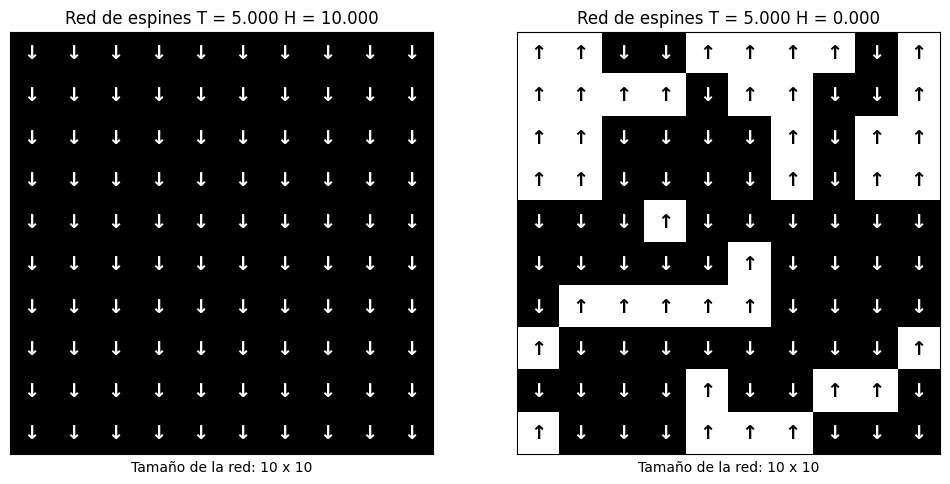

In [20]:
red_5_10 =  ising.generate_samples(L=10, T=4.0, samples=1, burn_in=1000, interval=100, seed=42, H=10, J=1, folder='./../data/')
red_5_0 =  ising.generate_samples(L=10, T=4.0, samples=1, burn_in=1000, interval=100, seed=42, H=0, J=1, folder='./../data/')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_spin(red_5_10, T=5.0, H=10, spin_arrows=True, ax=ax[0])
plot_spin(red_5_0, T=5.0, H=0, spin_arrows=True, ax=ax[1])

plt.show()

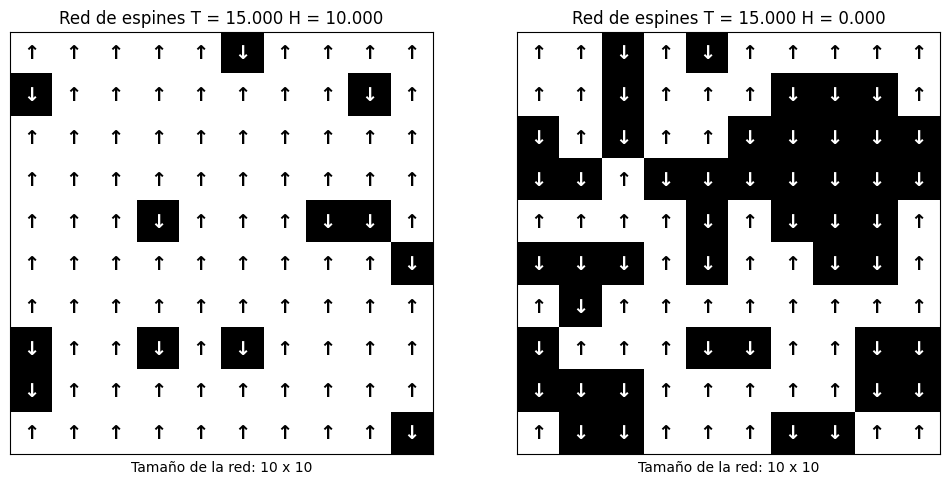

In [21]:
red_15_10 =  ising.generate_samples(L=10, T=15.0, samples=1, burn_in=1000, interval=100, seed=42, H=-10, J=1, folder='./../data/')
red_15_0 =  ising.generate_samples(L=10, T=15.0, samples=1, burn_in=1000, interval=100, seed=42, H=0, J=1, folder='./../data/')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_spin(red_15_10, T=15.0, H=10, spin_arrows=True, ax=ax[0])
plot_spin(red_15_0, T=15.0, H=0, spin_arrows=True, ax=ax[1])

plt.show()

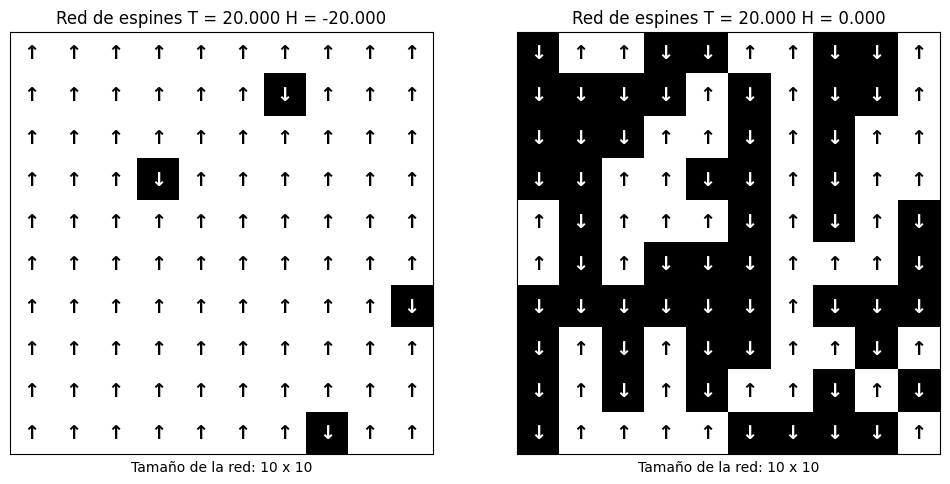

In [22]:
red_20_10 =  ising.generate_samples(L=10, T=15.0, samples=1, burn_in=1000, interval=100, seed=42, H=-20, J=1, folder='./../data/')
red_20_0 =  ising.generate_samples(L=10, T=15.0, samples=1, burn_in=1000, interval=100, seed=42, H=0, J=1, folder='./../data/')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_spin(red_20_10, T=20.0, H=-20, spin_arrows=True, ax=ax[0])
plot_spin(red_20_0, T=20.0, H=0, spin_arrows=True, ax=ax[1])

plt.show()


3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

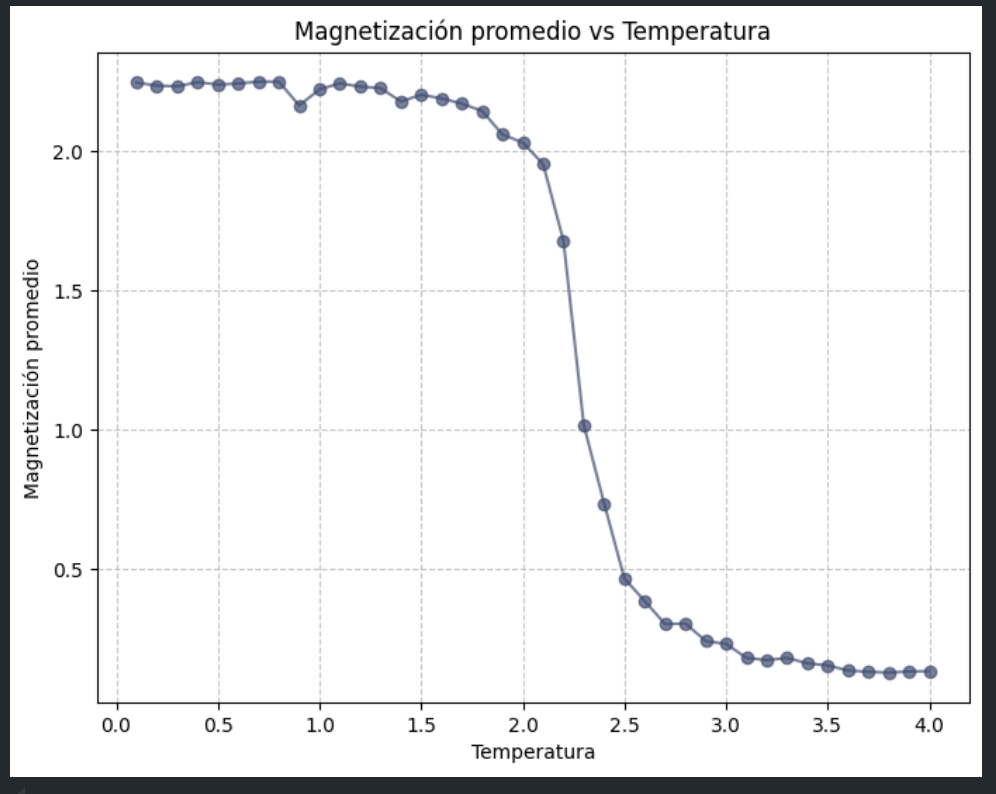

La figura anterior (sacada del trabajo que cite anteriormente) contiene la distribución promedio de magnetización vs temperatura en un sampleo de varias muestras generadas con el algoritmo, con todas las condiciones de termalización y relajación del algoritmo Metropolis-Hasting. Dónde notamos la coherencia de que la temperatura critica esta alrededor de $T=2.269$ como lo predice el modelo teórico 